In [1]:
import pandas as pd
import matplotlib.pyplot as plt #import plotting package
#render plotting automatically
%matplotlib inline
import matplotlib as mpl #additional plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high resolution figures
mpl.rcParams['font.size'] = 4 #font size for figures
from scipy import stats
import numpy as np

In [2]:
df = pd.read_csv('df_cleaned.csv')

In [3]:
bill_feats = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', \
              'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_feats = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', \
                 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [4]:
df[bill_feats].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,51405.730723,49300.001500,47026.340047,43338.894539,40338.136701,38889.872337
std,73633.687106,70934.549534,68705.359524,64275.250740,60705.944083,59432.541657
min,-165580.000000,-69777.000000,-157264.000000,-170000.000000,-81334.000000,-339603.000000
25%,3580.000000,2999.750000,2627.250000,2341.750000,1745.000000,1256.000000
50%,22361.000000,21150.000000,20079.500000,19037.000000,18066.000000,17005.000000
75%,67649.750000,64395.500000,60360.000000,54727.500000,50290.500000,49253.750000
max,746814.000000,671563.000000,855086.000000,706864.000000,823540.000000,699944.000000


We see that the average monthly bill is roughly 40,000 to 50,000 NT dollars. It seems reasonable.

We also notice there are some negative bill amounts. This seems reasonable
because of the possible overpayment of the previous month's bill, perhaps in
anticipation of a purchase that would show up on the current month's bill. A
scenario like this would leave that account with a negative balance, in the sense
of a credit to the account holder.

array([[<Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>]], dtype=object)

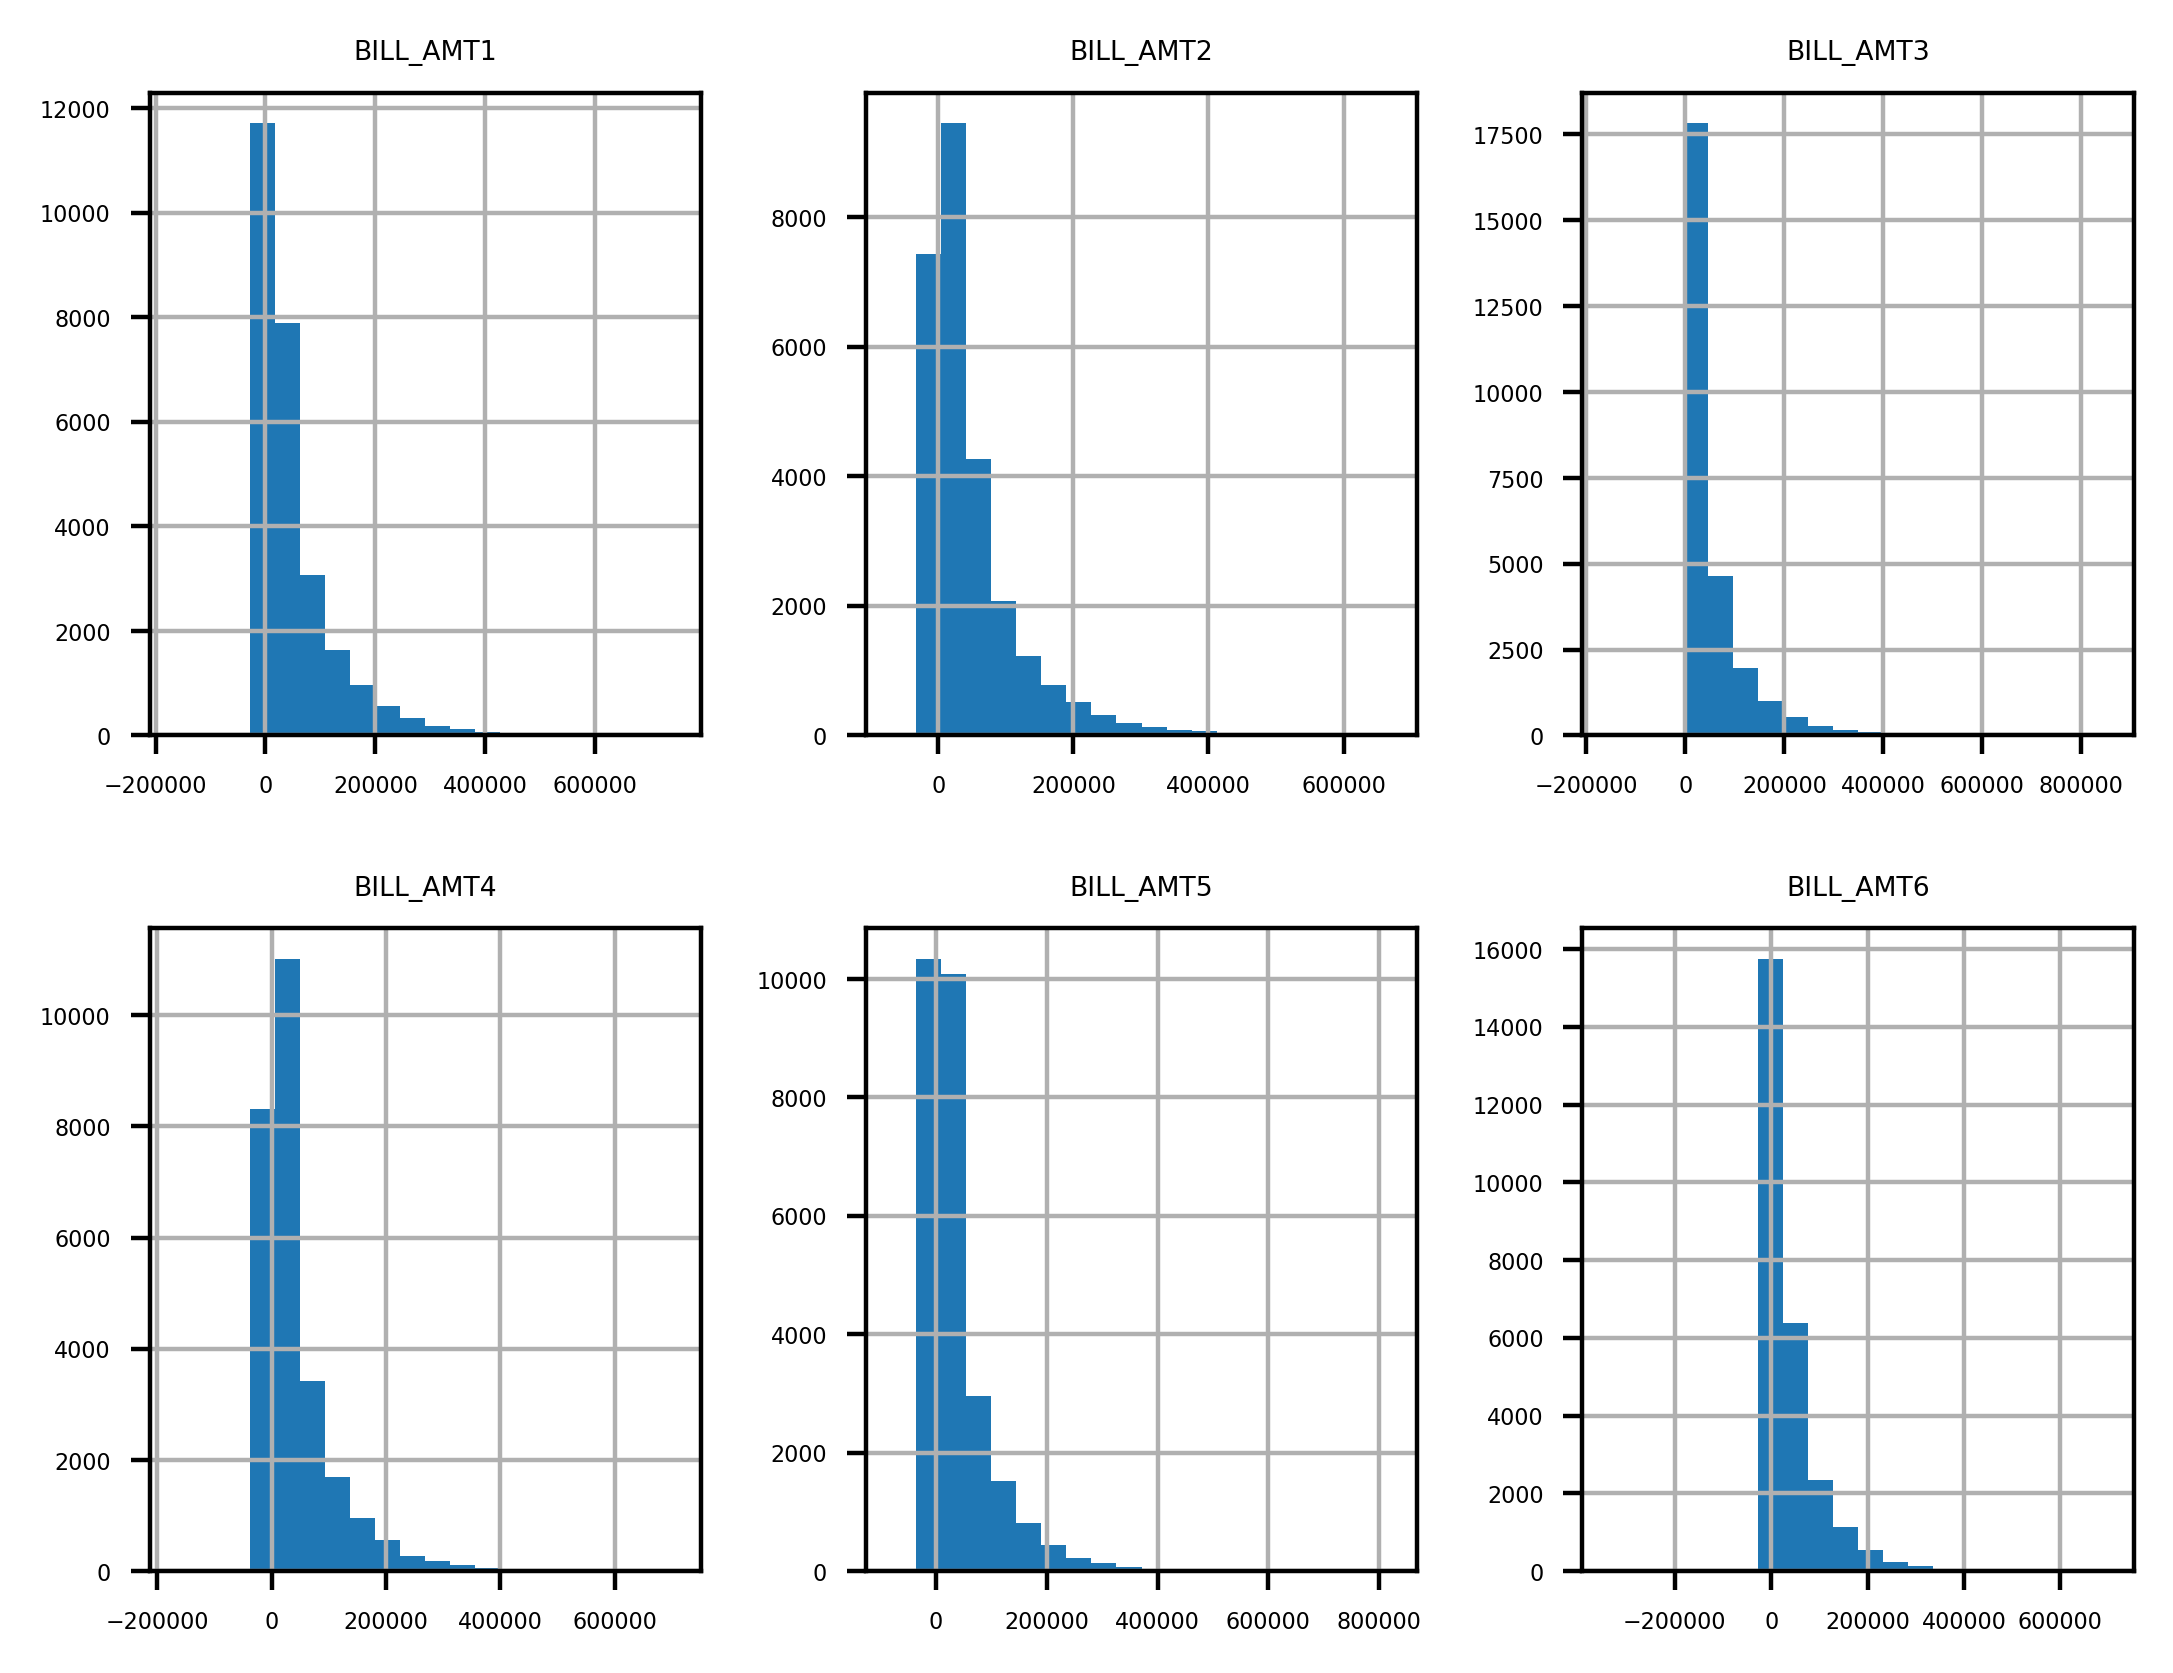

In [5]:
df[bill_feats].hist(bins=20, layout=(2,3))

Most accounts have relatively small bills. There is a steady decrease in the number of accounts
as the amount of the bill increases. It also appears that the distribution of
billed amounts is roughly similar month to month, so we don't notice any data
inconsistency issues as we did with the payment status features. This feature
appears to pass our data quality inspection. 

In [10]:
df[pay_amt_feats].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,26664.000000,2.666400e+04,26664.000000,26664.000000,26664.000000,26664.000000
mean,5704.085771,5.881110e+03,5259.514964,4887.048717,4843.729973,5257.843047
std,16699.398632,2.121431e+04,17265.439561,15956.349371,15311.721795,17635.468185
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,8.020000e+02,390.000000,294.750000,242.750000,111.000000
50%,2114.500000,2.007000e+03,1822.000000,1500.000000,1500.000000,1500.000000
75%,5027.000000,5.000000e+03,4556.250000,4050.500000,4082.750000,4015.000000
max,873552.000000,1.227082e+06,889043.000000,621000.000000,426529.000000,528666.000000


The average payment amounts are about an order of magnitude (power of 10)
lower than the average bill amounts we summarized earlier in the activity. This
means that the "average case" is an account that is not paying off its entire
balance from month to month. This makes sense in light of our exploration of
the PAY_1 feature, for which the most prevalent value was 0 (the account made
at least the minimum payment but did not pay off the whole balance). There are
no negative payments, which also seems right.

array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

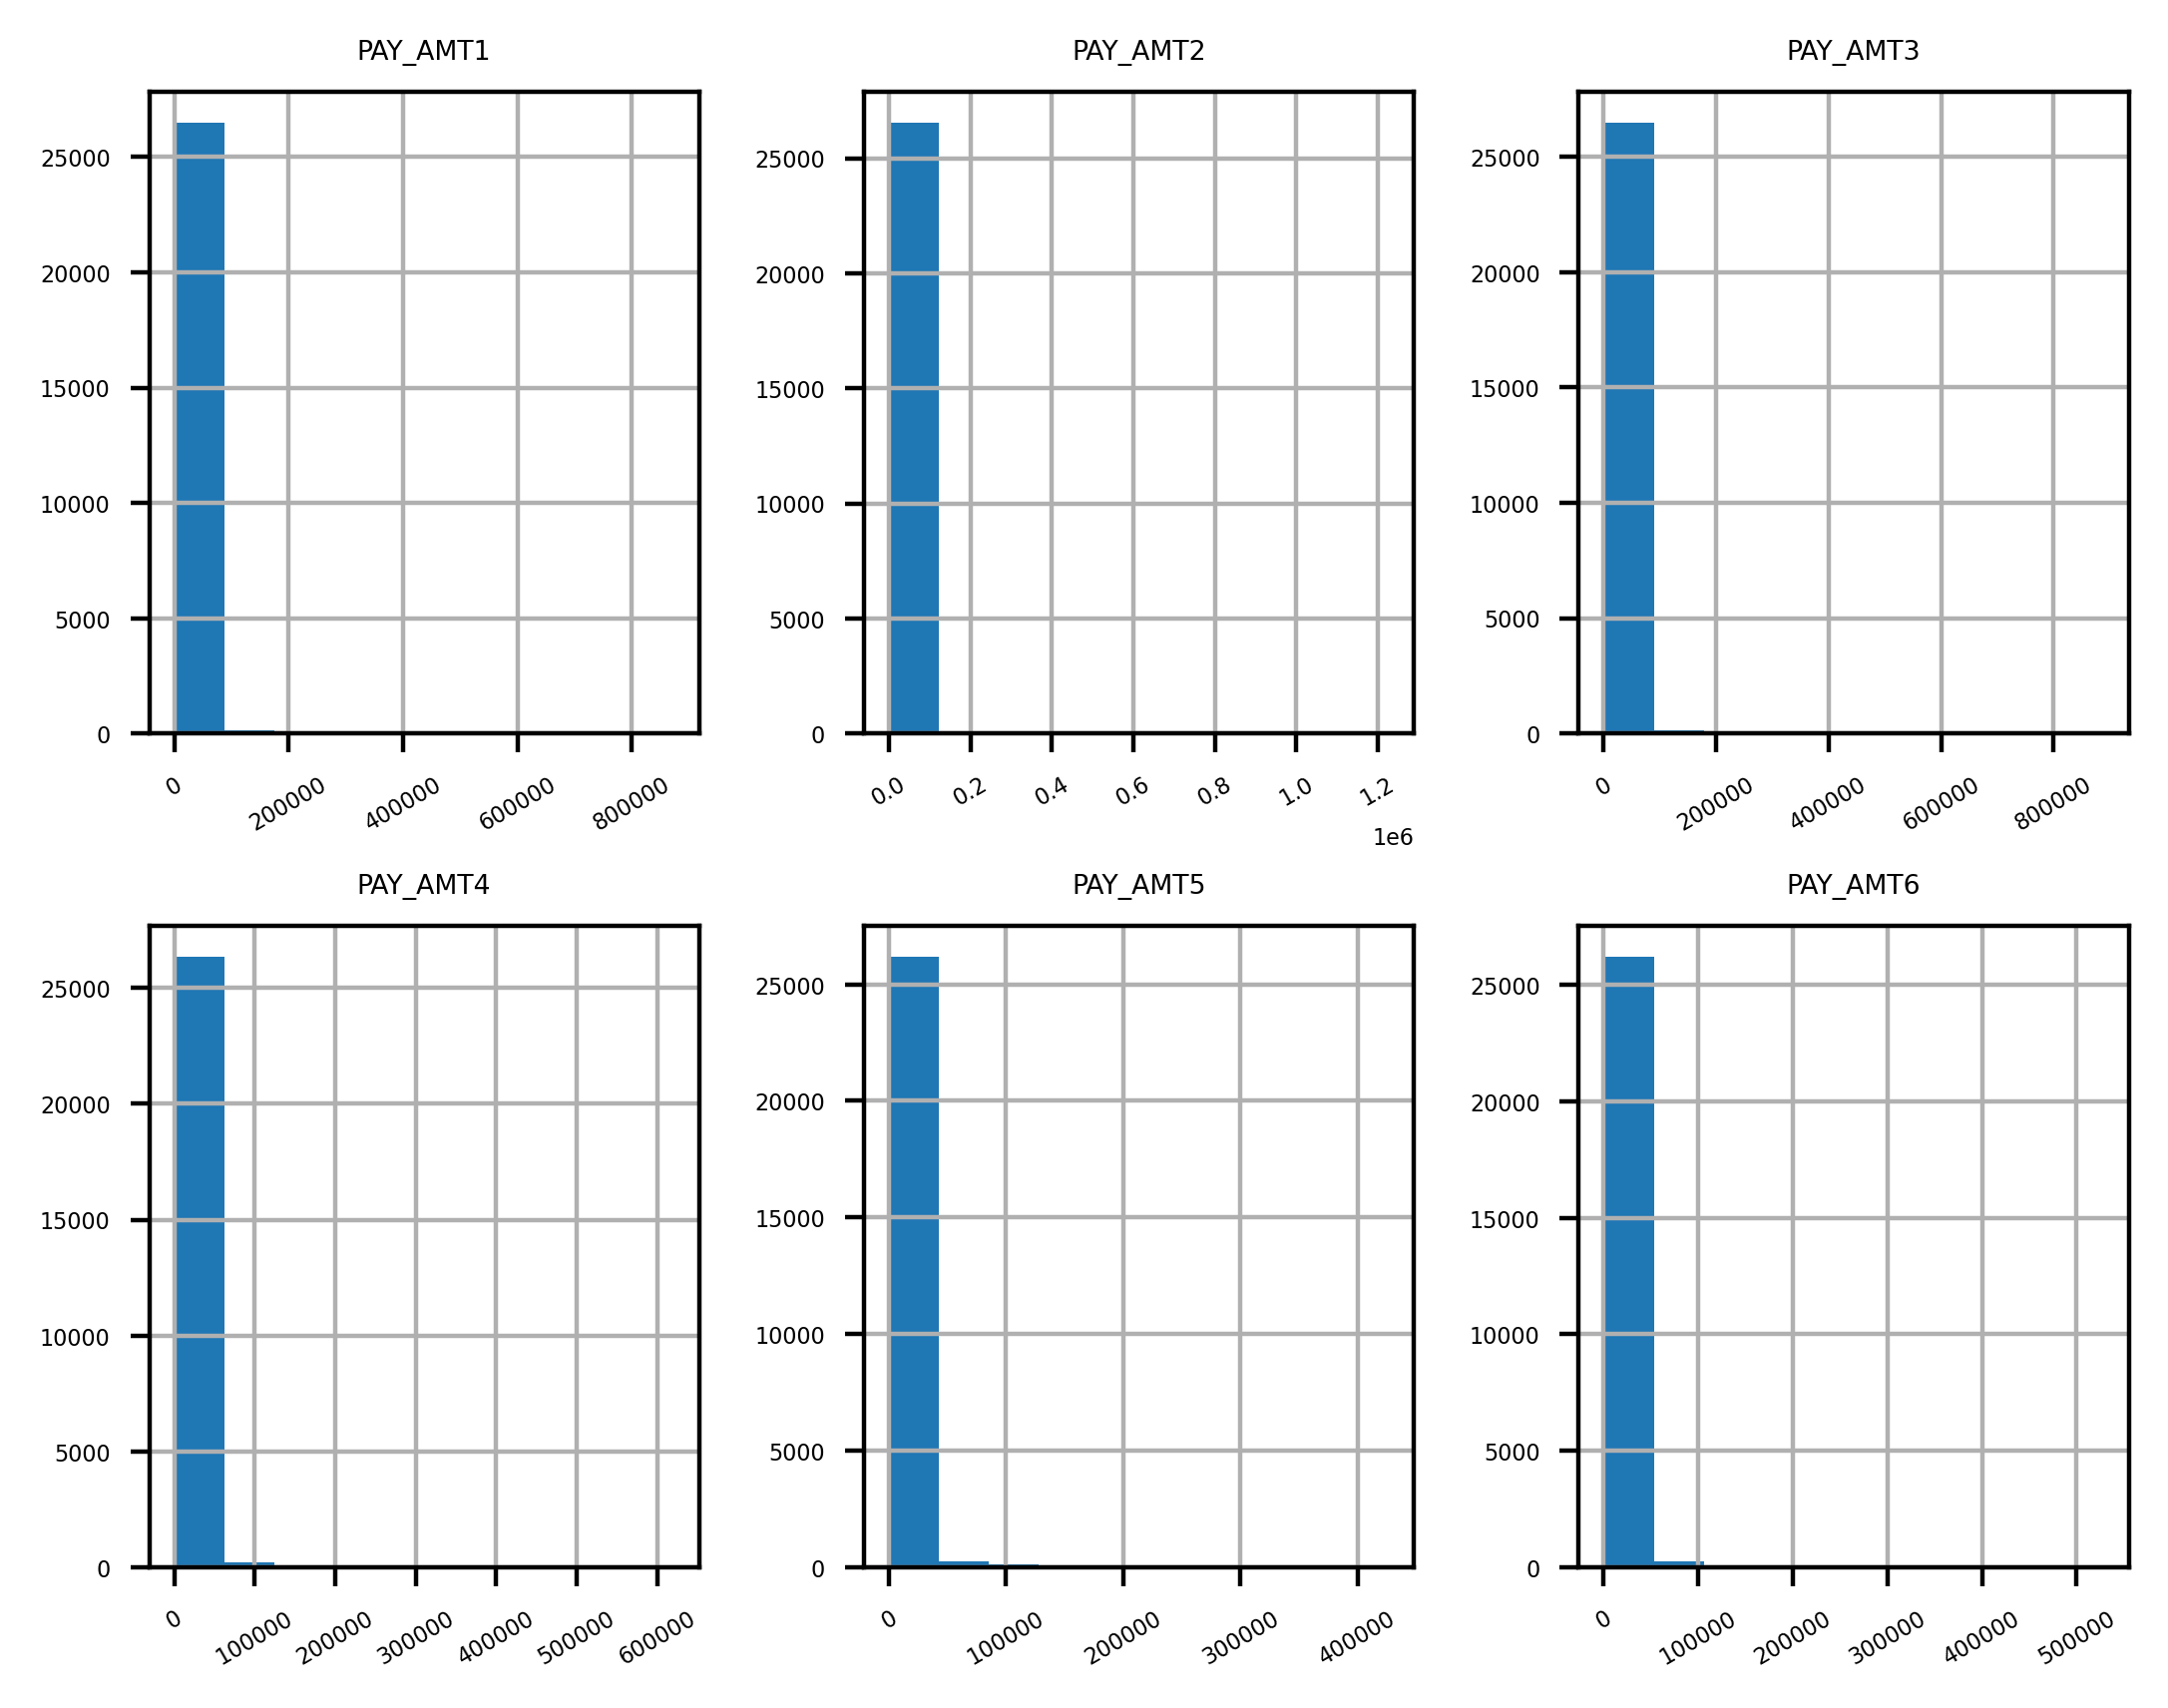

In [11]:
df[pay_amt_feats].hist(layout=(2,3), xrot=30)

A quick glance at this figure indicates that this is not a very informative graphic;
there is only one bin in most of the histograms that is of a noticeable height. This
is not an effective way to visualize this data. It appears that the monthly payment
amounts are mainly in a bin that includes 0. How many are in fact 0?

In [14]:
pay_zero_mask = df[pay_amt_feats] == 0
pay_zero_mask.sum()

PAY_AMT1    4656
PAY_AMT2    4833
PAY_AMT3    5293
PAY_AMT4    5697
PAY_AMT5    5981
PAY_AMT6    6373
dtype: int64

We see that a substantial portion, roughly around 20-25% of accounts, have a bill
payment equal to 0 in any given month. However, most bill payments are above
0. So, why can't we see them in the histogram? This is due to the range of values
for bill payments relative to the values of the majority of the bill payments.

In the statistical summary, we can see that the maximum bill payment in a
month is typically 2 orders of magnitude (100 times) larger than the average
bill payment. It seems likely there are only a small number of these very large
bill payments. But, because of the way the histogram is created, using equalsized bins, nearly all the data is lumped into the smallest bin, and the larger bins
are nearly invisible because they have so few accounts. We need a strategy to
effectively visualize this data.

array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

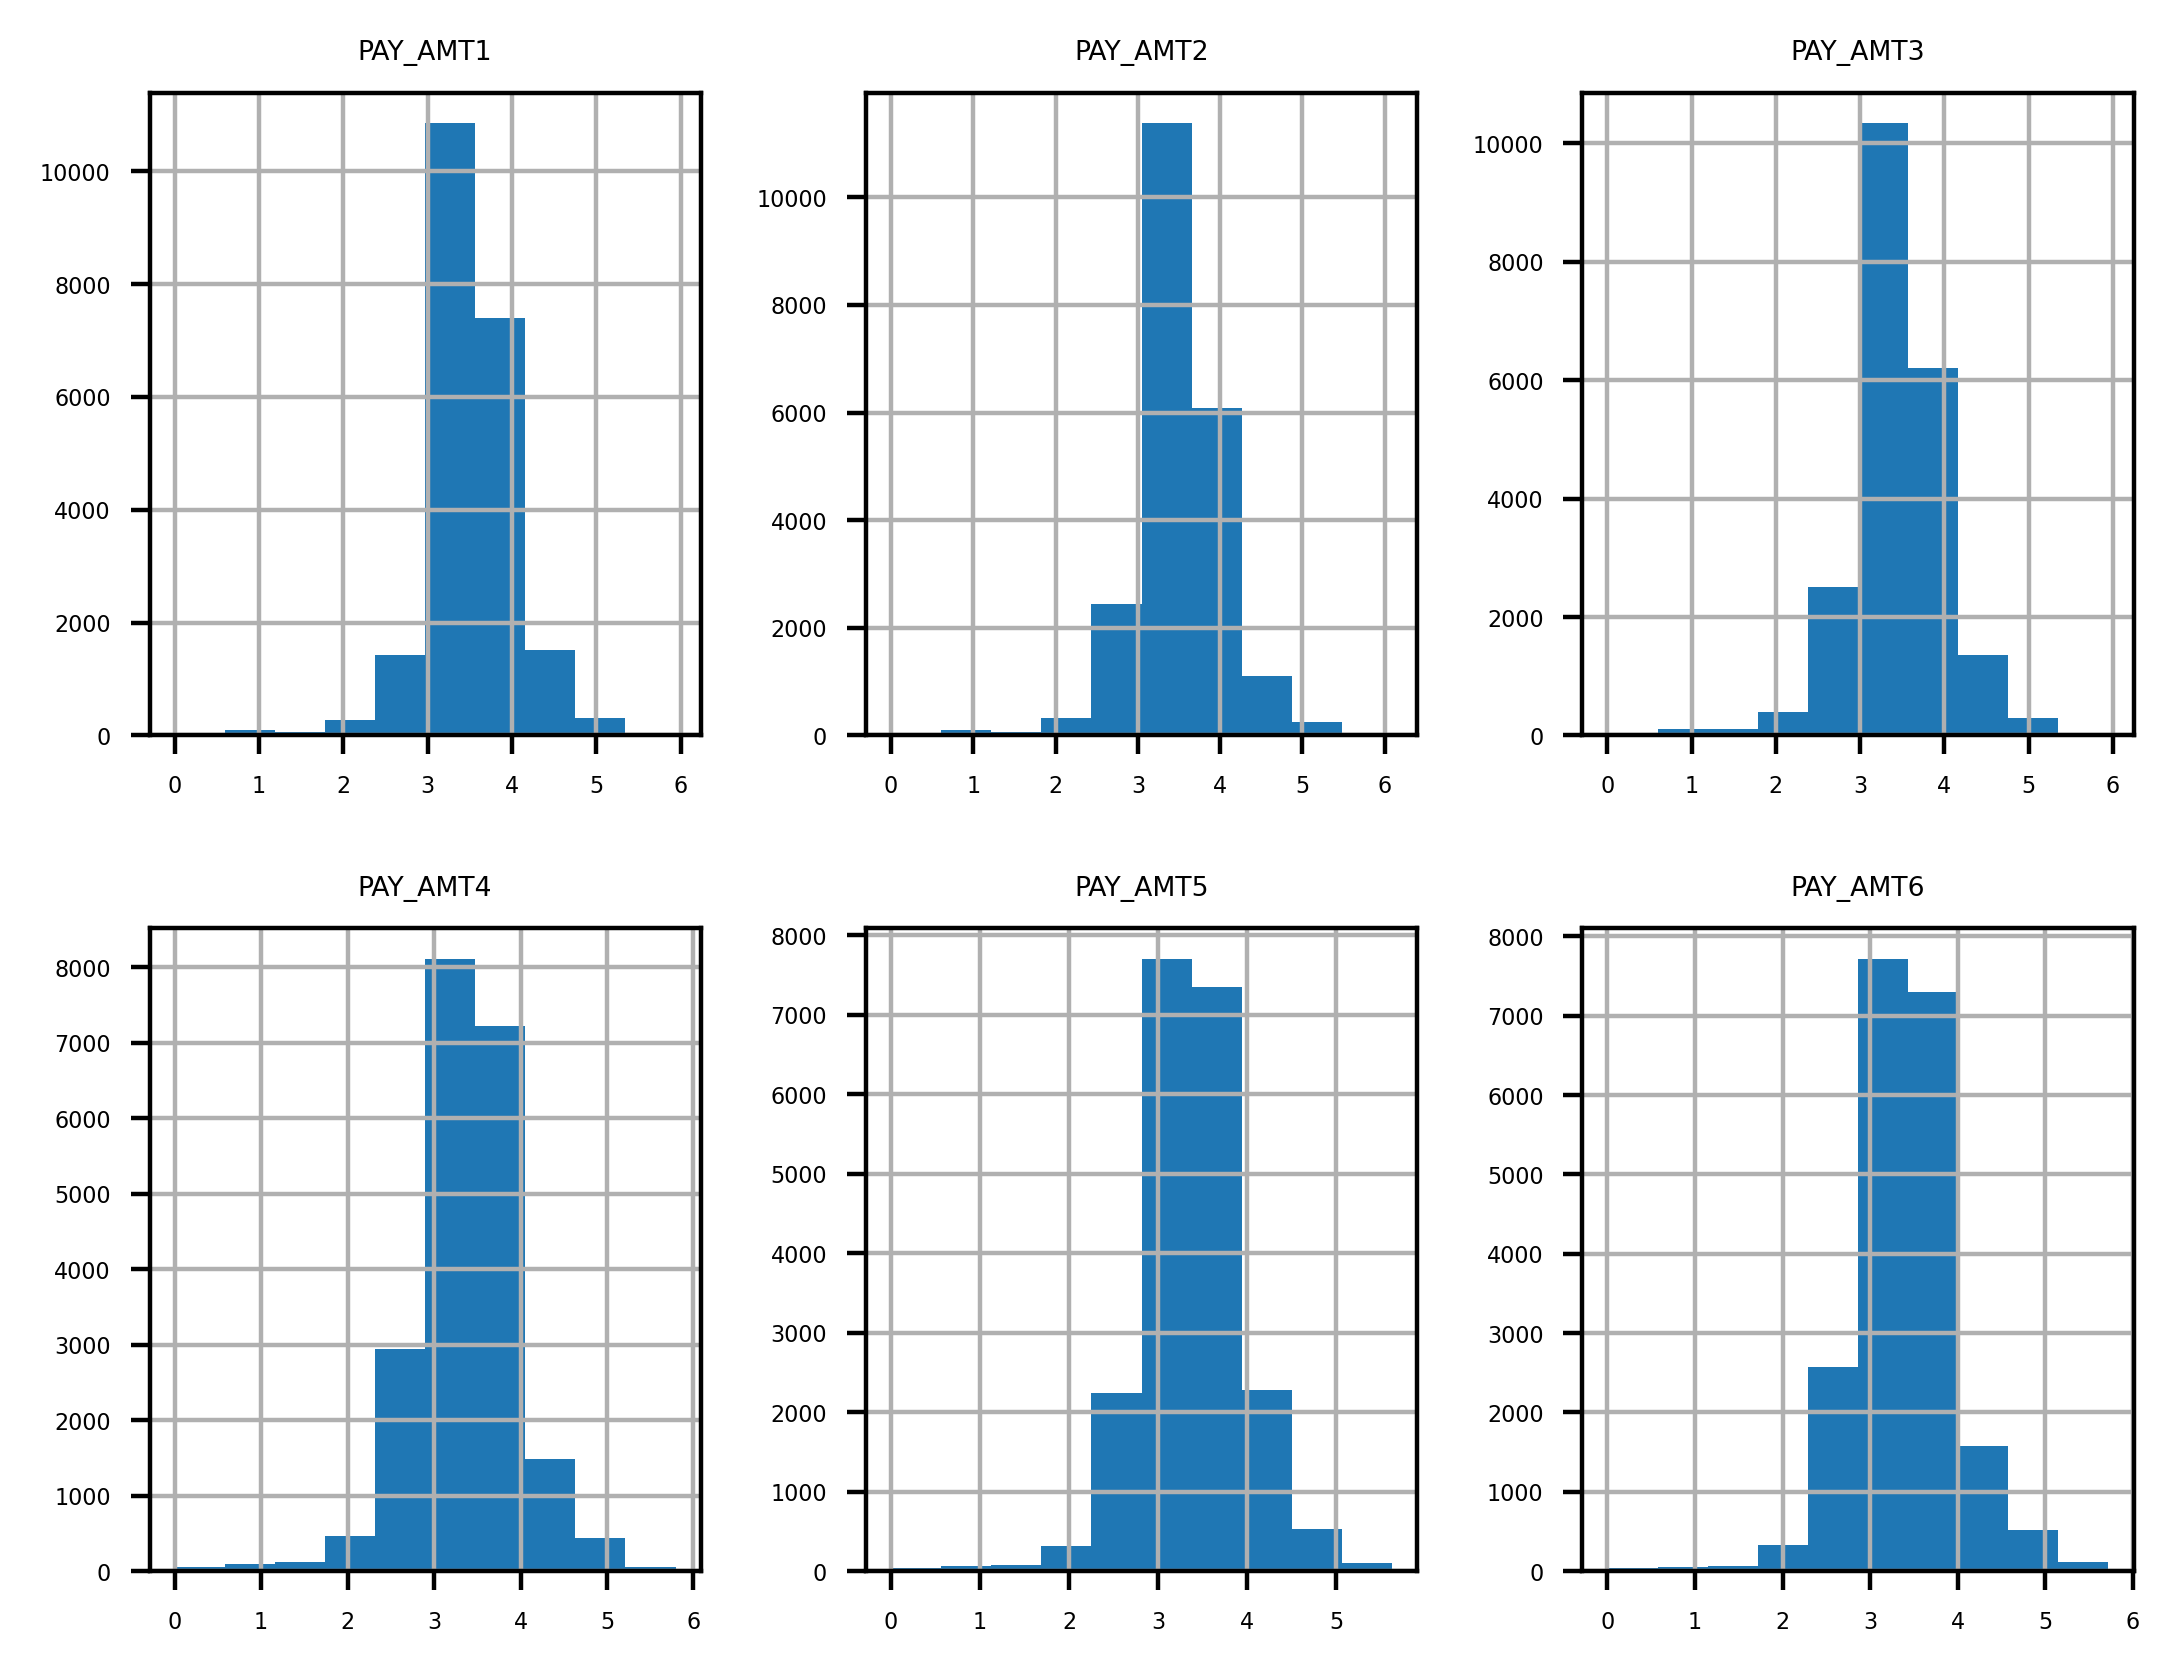

In [15]:
df[pay_amt_feats][~pay_zero_mask].apply(np.log10).hist(layout=(2,3))

The result is a more effective data visualization: the values are spread in a more
informative way across the histogram bins. We can see that the most commonly
occurring bill payments are in the range of thousands (log10(1,000) = 3), which
matches what we observed for the mean bill payment in the statistical summary.
There are some pretty small bill payments, and also a few pretty large ones. Overall,
the distribution of bill payments appears pretty consistent from month to month, so
we don't see any potential issues with this data.